# 10 - Model Performance Comparison

## Purpose

This notebook compares the performance of Linear Regression, Random Forest and XGBoost for dissolved oxygen forecasting.

The models are evaluated across eight prediction horizons from 15 to 120 minutes using MAE, RMSE and R².

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
DATA_FILE = PROJECT_ROOT / "data" / "processed" / "do_prediction_model_performance.csv"

df = pd.read_csv(DATA_FILE)

print("Rows:", len(df))
print(df.columns.tolist())

df.head()

Rows: 48
['target_type', 'horizon', 'target_column', 'model', 'MAE', 'RMSE', 'R2', 'train_rows', 'test_rows']


,target_type,horizon,target_column,model,MAE,RMSE,R2,train_rows,test_rows
0,DO mg/L,15min,do_mgl_next_15min,Linear Regression,0.059432,0.142753,0.994124,86376,21595
1,DO mg/L,15min,do_mgl_next_15min,Random Forest,0.188645,0.425200,0.947869,86376,21595
2,DO mg/L,15min,do_mgl_next_15min,XGBoost,0.499451,0.694252,0.861024,86376,21595
3,DO %,15min,do_pct_next_15min,Linear Regression,0.486125,1.264440,0.991258,86376,21595
4,DO %,15min,do_pct_next_15min,Random Forest,0.578053,1.538240,0.987062,86376,21595


In [2]:
do_mgl = df[
    df["target_type"].astype(str).str.lower() == "do mg/l"
].copy()

do_mgl["R2"] = pd.to_numeric(do_mgl["R2"], errors="coerce")
do_mgl["RMSE"] = pd.to_numeric(do_mgl["RMSE"], errors="coerce")
do_mgl["MAE"] = pd.to_numeric(do_mgl["MAE"], errors="coerce")

do_mgl.sort_values(["horizon", "R2"], ascending=[True, False]).head(20)

,target_type,horizon,target_column,model,MAE,RMSE,R2,train_rows,test_rows
36,DO mg/L,105min,do_mgl_next_105min,Linear Regression,0.195606,0.427643,0.947274,86362,21591
38,DO mg/L,105min,do_mgl_next_105min,XGBoost,0.413213,0.690769,0.862429,86362,21591
37,DO mg/L,105min,do_mgl_next_105min,Random Forest,0.360648,0.727033,0.847605,86362,21591
42,DO mg/L,120min,do_mgl_next_120min,Linear Regression,0.214726,0.456126,0.940018,86360,21590
44,DO mg/L,120min,do_mgl_next_120min,XGBoost,0.292374,0.610405,0.892580,86360,21590
43,DO mg/L,120min,do_mgl_next_120min,Random Forest,0.355647,0.712850,0.853497,86360,21590
0,DO mg/L,15min,do_mgl_next_15min,Linear Regression,0.059432,0.142753,0.994124,86376,21595
1,DO mg/L,15min,do_mgl_next_15min,Random Forest,0.188645,0.425200,0.947869,86376,21595
2,DO mg/L,15min,do_mgl_next_15min,XGBoost,0.499451,0.694252,0.861024,86376,21595
6,DO mg/L,30min,do_mgl_next_30min,Linear Regression,0.085146,0.200089,0.988456,86374,21594


In [3]:
best_models = (
    do_mgl
    .sort_values(["horizon", "R2"], ascending=[True, False])
    .groupby("horizon", as_index=False)
    .first()
)

best_models[
    ["horizon", "model", "MAE", "RMSE", "R2"]
]

,horizon,model,MAE,RMSE,R2
0,105min,Linear Regression,0.195606,0.427643,0.947274
1,120min,Linear Regression,0.214726,0.456126,0.940018
2,15min,Linear Regression,0.059432,0.142753,0.994124
3,30min,Linear Regression,0.085146,0.200089,0.988456
4,45min,Linear Regression,0.108538,0.247535,0.982333
5,60min,Linear Regression,0.129906,0.282753,0.976948
6,75min,Linear Regression,0.152506,0.334699,0.967701
7,90min,Linear Regression,0.174986,0.388585,0.956464


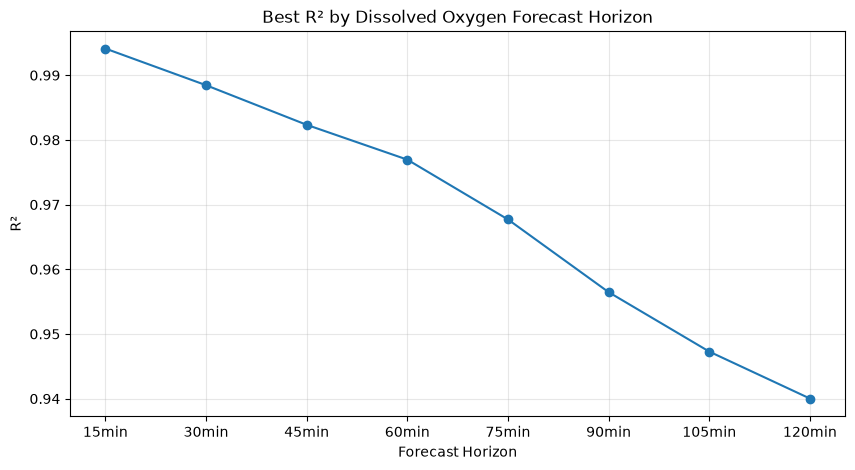

In [4]:
order = [
    "15min", "30min", "45min", "60min",
    "75min", "90min", "105min", "120min"
]

plot_data = best_models.copy()
plot_data["horizon"] = pd.Categorical(
    plot_data["horizon"],
    categories=order,
    ordered=True
)

plot_data = plot_data.sort_values("horizon")

plt.figure(figsize=(10, 5))
plt.plot(
    plot_data["horizon"],
    plot_data["R2"],
    marker="o"
)

plt.title("Best R² by Dissolved Oxygen Forecast Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("R²")
plt.grid(alpha=0.3)
plt.show()

## Interpretation

The comparison showed that Linear Regression produced the highest R² for each of the eight DO mg/L forecasting horizons used by the final AquaPulse live application.

Performance gradually decreased as the forecasting horizon increased, which is expected because longer-term forecasts contain greater uncertainty.

The model comparison demonstrates that greater algorithm complexity did not automatically produce better performance for the River Derwent dataset.